# Pan-Tompkins Algorithm — Online Real-Time Detection

The Pan–Tompkins algorithm is a classical real-time QRS-complex detection
algorithm designed to identify QRS complexes and R-peaks from an ECG signal.

In this notebook, the algorithm will be reconstructed and implemented with
the original real-time processing paradigm in mind. Unlike offline processing,
the ECG signal is assumed to arrive sequentially, and the detector must make
decisions using only the samples available at the current time.

Each processing stage will first be understood theoretically, then implemented,
visualized, inspected, and finally integrated into the complete real-time
detector.

The objective is to reconstruct a streaming-oriented QRS detection system that
can later be adapted to embedded or wearable hardware.

The complete processing chain is:

ECG Stream
→ Real-Time Filtering
→ Derivative
→ Squaring
→ Moving-Window Integration
→ Peak/Candidate Detection
→ Adaptive Thresholding
→ Decision Logic
→ Search-Back
→ R-Peak Localization
→ R-Peak Output

The final detector should produce R-peak locations sequentially as new ECG
samples become available.

## 1. Setup and Developement Data

In [1]:
# Import libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

# Define the project paths
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
MITDB_DIR = RAW_DATA_DIR / "mit-bih-arrhythmia"


In [2]:
# Get one record to be used for the development procedure
record_name = "100"
record = wfdb.rdrecord(str(MITDB_DIR / record_name))

signal_original = record.p_signal[:, 0]                         # The original signal - Channel 1
fs_original = record.fs                                         # Original sampling frequency of the record
time_original = np.arange(len(signal_original)) / fs_original   # Original time vector

# Target sampling frequency: In the original Pan-tompkins paper 
# but we adapt to the fs we have depending on the performance and the results we achieve
fs = 200

## 2. Resample


In [3]:
def resample_signal(signal, original_fs:float, target_fs:float=200):
    """
    Resample a discrete signal to a target sampling frequency using
    linear interpolation.

    Parameters
    ----------
    signal : array_like
        Input discrete-time signal.
    original_fs : float
        Sampling frequency of the input signal in Hz.
    target_fs : float, optional
        Desired sampling frequency in Hz. Default is 200 Hz.

    Returns
    -------
    resampled_signal : ndarray
        Signal resampled at the target sampling frequency.
    new_time : ndarray
        Time vector corresponding to the resampled signal, in seconds.
    """

    # Calculate original time vector
    original_time = np.arange(len(signal)) / original_fs

    # Calculate new length = new number of samples
    new_length = int(len(signal) * target_fs / original_fs )

    # Calculate new time vector considering the new length and target sampling frequency
    new_time = np.arange(new_length) / target_fs

    # Apply linear interpolation
    resampled_signal = np.interp(new_time, original_time, signal)

    return resampled_signal, new_time

In [4]:
resampled_ecg, resampled_time = resample_signal(signal_original, fs_original, fs)

In [5]:
print(f"Original sampling frequency: {fs_original} Hz")
print(f"New sampling frequency: {fs} Hz")
print(f"Original samples: {len(signal_original)}")
print(f"Resampled samples: {len(resampled_ecg)}")
print(f"Time vector after resampling (First 5 timestamps): {resampled_time[:5]}")

Original sampling frequency: 360 Hz
New sampling frequency: 200 Hz
Original samples: 650000
Resampled samples: 361111
Time vector after resampling (First 5 timestamps): [0.    0.005 0.01  0.015 0.02 ]


In [6]:
# Number of samples in 10 seconds - Resampled signal
n_samples_to_plot_res = int(10 * fs)
# Number of samples in 10 seconds - Original signal
n_samples_to_plot_org = int(10 * fs_original)

# Ten second signal and time vector for the original signal
ten_sec_ecg_time_org = time_original[: n_samples_to_plot_org]
ten_sec_ecg_sig_org = signal_original[: n_samples_to_plot_org]

# Ten second signal and time vector for the resampled signal
ten_sec_ecg_time_res = resampled_time[:n_samples_to_plot_res]
ten_sec_ecg_sig_res = resampled_ecg[:n_samples_to_plot_res]

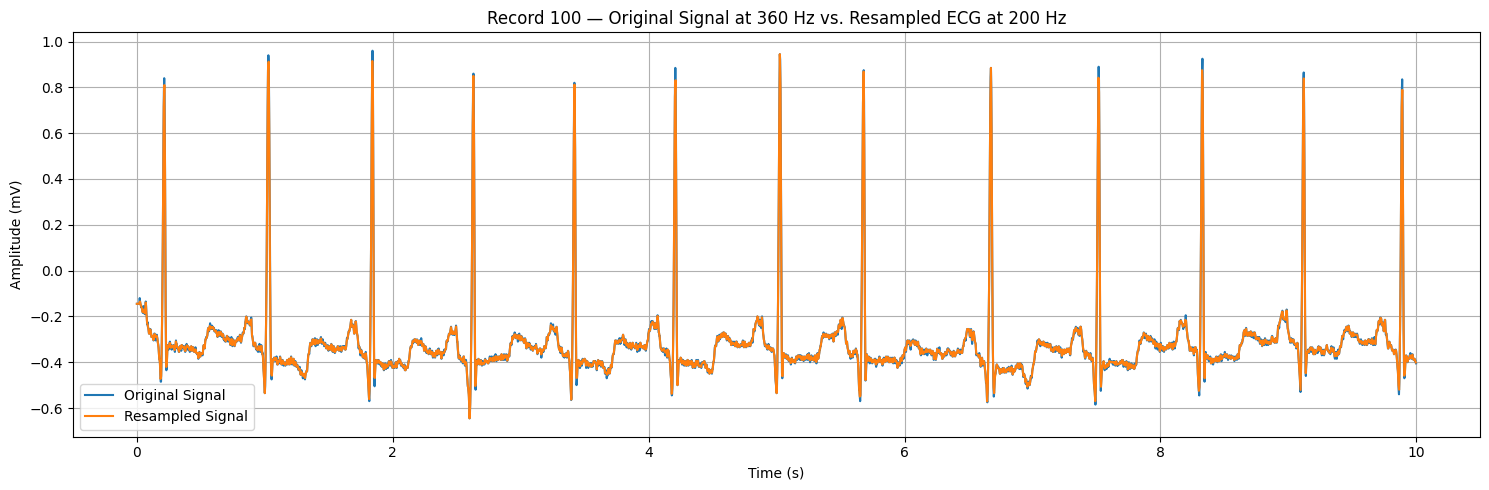

In [7]:
plt.figure(figsize=(15, 5))

plt.plot(
    ten_sec_ecg_time_org,
    ten_sec_ecg_sig_org, label="Original Signal"
)
plt.plot(
    ten_sec_ecg_time_res,
    ten_sec_ecg_sig_res, label="Resampled Signal"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Original Signal at 360 Hz vs. Resampled ECG at 200 Hz")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## 3. Band-Pass Filter

In [8]:
# History / memory for band-pass filtration
input_history = []
lp_history = []
hp_history = []

In [9]:
def band_pass_filter(sample:float):
    """
    Process one incoming ECG sample through the recursive band-pass
    filter used in the online Pan-Tompkins algorithm.

    The filter consists of a low-pass stage followed by a high-pass
    stage. Both stages are implemented using the recursive difference
    equations defined by the original Pan-Tompkins method. Unlike the
    offline implementation, this method processes one sample at a time
    and maintains the previous input and filter-output samples in
    persistent history buffers.

    Parameters
    ----------
    sample : float
        Current ECG sample to be processed.

    Returns
    -------
    y_hp : float
        Current high-pass filter output, corresponding to the
        band-pass-filtered ECG sample.

    Notes
    -----
    The filter is implemented directly from the recursive difference
    equations rather than using a general-purpose digital filter design
    routine. The output is not amplitude-normalized.

    The filter stages are:

        Low-Pass:
            y_LP[n] = 2y_LP[n−1] − y_LP[n−2]
                      + x[n] − 2x[n−6] + x[n−12]

        High-Pass:
            y_HP[n] = 32y_LP[n−16] − y_HP[n−1]
                      − y_LP[n] + y_LP[n−32]

    The method is stateful: previous input samples and filter outputs
    are required to calculate the current output. Therefore, samples
    must be supplied sequentially.

    In the online implementation, the required previous samples are
    maintained in memory rather than recomputing the filter over the
    complete ECG signal for every new sample.

    The filter corresponds to the recursive band-pass filtering stage
    of the Pan-Tompkins QRS detection algorithm and is intended for
    sample-by-sample real-time processing.
    """

    # Store the new input sample
    input_history.append(sample)

    # Current sample index
    n = len(input_history) - 1

    # Initialize current low-pass output
    y_lp = input_history[n]

    # Apply 2y[n-1]
    if n >= 1:
        y_lp += 2 * lp_history[n - 1]

    # Apply -y[n-2]
    if n >= 2:
        y_lp -= lp_history[n - 2]

    # Apply -2x[n-6]
    if n >= 6:
        y_lp -= 2 * input_history[n - 6]

    # Apply x[n-12]
    if n >= 12:
        y_lp += input_history[n - 12]

    # Store the current low-pass output
    lp_history.append(y_lp)

    # Initialize y[n] = -x[n]
    y_hp = -1 * y_lp

    # Apply 32x[n−16]
    if n >= 16:
        y_hp += 32 * lp_history[n - 16]

    # Apply −y[n−1]
    if n >= 1:
        y_hp -= hp_history[n - 1]

    # Apply x[n−32]
    if n >= 32:
        y_hp += lp_history[n - 32]

    # Store current high-pass output
    hp_history.append(y_hp)

    return y_hp



**Sampling-rate investigation:** The original MIT-BIH signal was processed at 360 Hz and compared with a 200-Hz resampled version. Applying the same fixed-delay recursive filter equations at the two sampling rates produced visibly different temporal and amplitude characteristics, illustrating the dependence of the filter implementation on sampling frequency.

> Therefore we use 360 Hz fs of the original ECG signal due to the desired characteristics and results that we get from it compared to when using resampled 200 Hz signal.

In [10]:
# Clear history
input_history.clear()
lp_history.clear()
hp_history.clear()

# Just to inspect and test, we simulate the real-time sampling 
for sample in ten_sec_ecg_sig_org:
    band_pass_filter(sample)


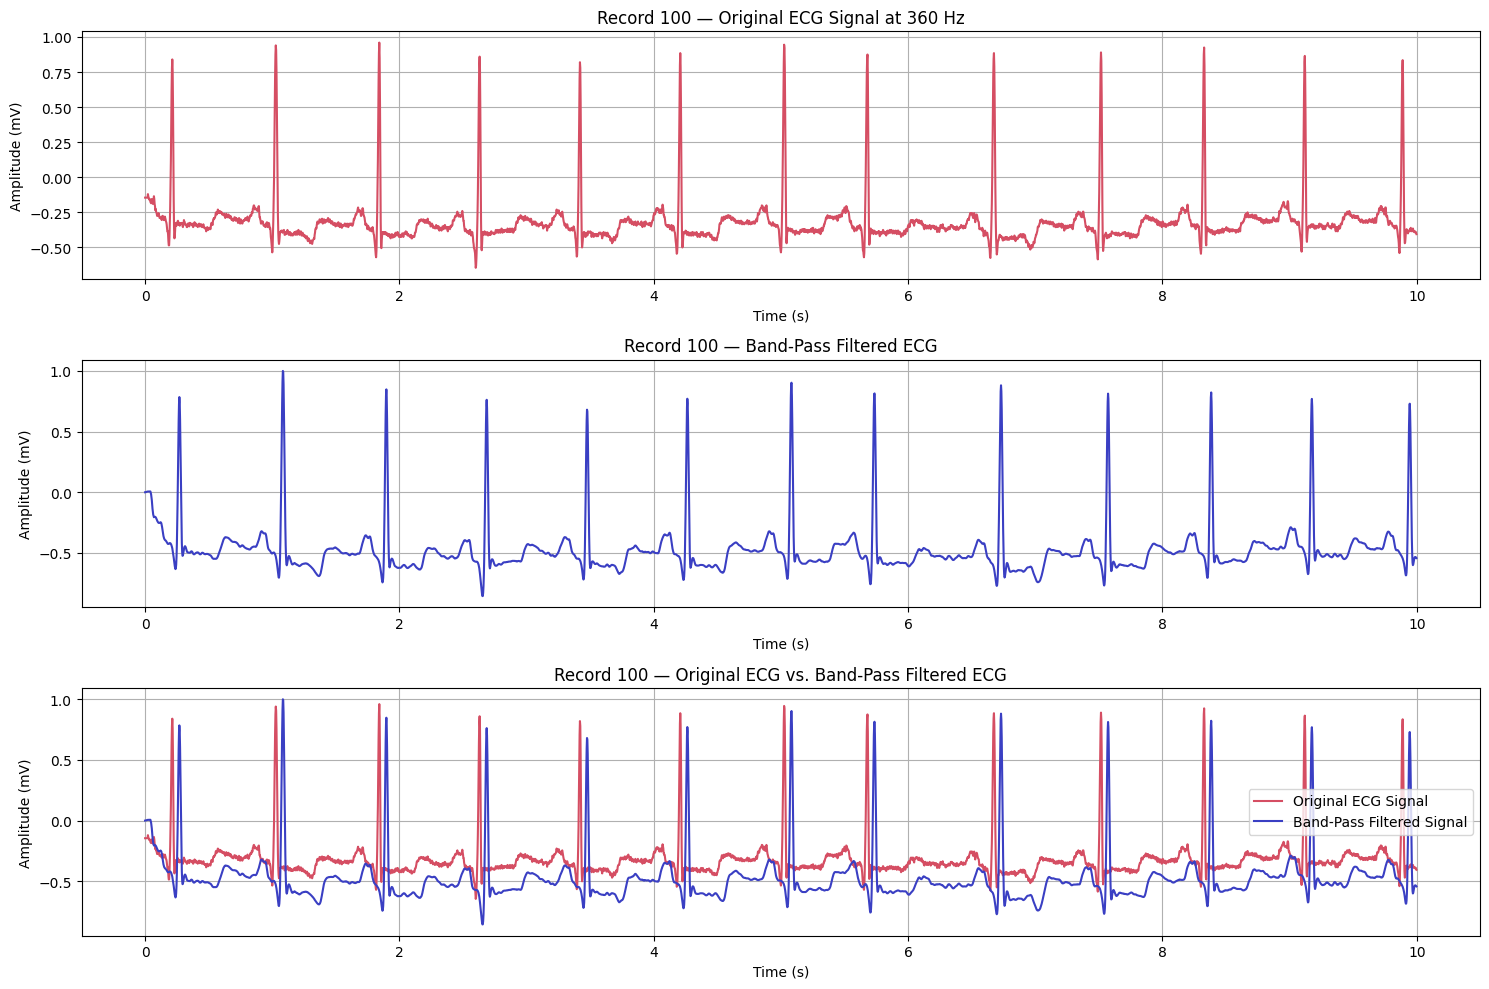

In [11]:
# Normalize for visualization
normalized_filtered = hp_history[:len(ten_sec_ecg_time_org)] / np.max(np.abs(hp_history[:len(ten_sec_ecg_time_org)]))

# Visualize 
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(ten_sec_ecg_time_org, ten_sec_ecg_sig_org, color="#d54e63")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Original ECG Signal at 360 Hz")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(ten_sec_ecg_time_org, normalized_filtered, color="#3a3fc3")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Band-Pass Filtered ECG")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(ten_sec_ecg_time_org, ten_sec_ecg_sig_org, color="#d54e63", label="Original ECG Signal")
plt.plot(ten_sec_ecg_time_org, normalized_filtered, color="#3a3fc3", label="Band-Pass Filtered Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Original ECG vs. Band-Pass Filtered ECG")
plt.grid()

plt.legend()
plt.tight_layout()
plt.show()

## 4. Derivative

In [12]:
# History / Memory for derivative 
derivative_history = []
y_derivative = [] 

In [13]:
def derivative(sample:float, fs:float):
    """
    Compute the derivative of one incoming ECG sample using the
    five-point finite-difference equation from the Pan-Tompkins algorithm.

    The function operates sequentially on one incoming sample at a time.
    Each sample is stored in an internal history buffer. Once at least
    five samples are available, the derivative of the center sample is
    calculated using the two preceding and two succeeding samples.
    Consequently, the computed derivative corresponds to a sample that
    is two samples behind the most recently received sample.

    Parameters
    ----------
    sample : float
        Current band-pass-filtered ECG sample.
    fs : float
        Sampling frequency of the input ECG signal in Hz.

    Returns
    -------
    float
        Computed derivative sample. During the initial warm-up period,
        when fewer than five samples are available, 0.0 is returned.

    Notes
    -----
    The derivative is computed using the five-point finite-difference
    equation:

        y[n] = (-x[n-2] - 2x[n-1] + 2x[n+1] + x[n+2]) / (8T)

    where T = 1 / fs is the sampling period.

    Because the equation requires two future samples, the derivative
    output is delayed by two samples relative to the incoming signal.
    The first valid derivative is therefore obtained after five input
    samples have been received.

    The derivative history stores the incoming filtered samples and
    serves as the memory required for sequential online processing.
    """
    
    # Compute T = 1 / Fs
    T = 1 / fs

    # Store the sample
    derivative_history.append(sample)

    # Current sample index 
    n = len(derivative_history) - 1

    # Initialize current derivative output
    y_der = derivative_history[n] 

    # Apply 5-point derivative 
    if len(derivative_history) >= 5:
        # Samples center, e.g: [0, 1, 2, 3, 4] --> if n = 4 then center = 2
        center = n - 2

        # Calculate derivative of sample
        y_der = (
            - derivative_history[center - 2]
            - 2 * derivative_history[center - 1]
            + 2 * derivative_history[center + 1]
            + derivative_history[center + 2]
        )
        
        y_der /= 8 * T

        # Add current calculated output to the output list
        y_derivative.append(y_der)

    else:
        # Just in case of indexing error
        return 0.0
    
    return y_der


In [14]:
# Clear history
input_history.clear()
lp_history.clear()
hp_history.clear()
derivative_history.clear()
y_derivative.clear()

# Just to inspect and test, we simulate the real-time sampling 
for sample_der in ten_sec_ecg_sig_org:
    filtered_sample = band_pass_filter(sample_der)
    derivative_sample = derivative(filtered_sample, fs_original)

In [15]:
# Padding is used to maintain alignment/length for visualization
y_derivative_pad = [0.0, 0.0, 0.0, 0.0] + y_derivative

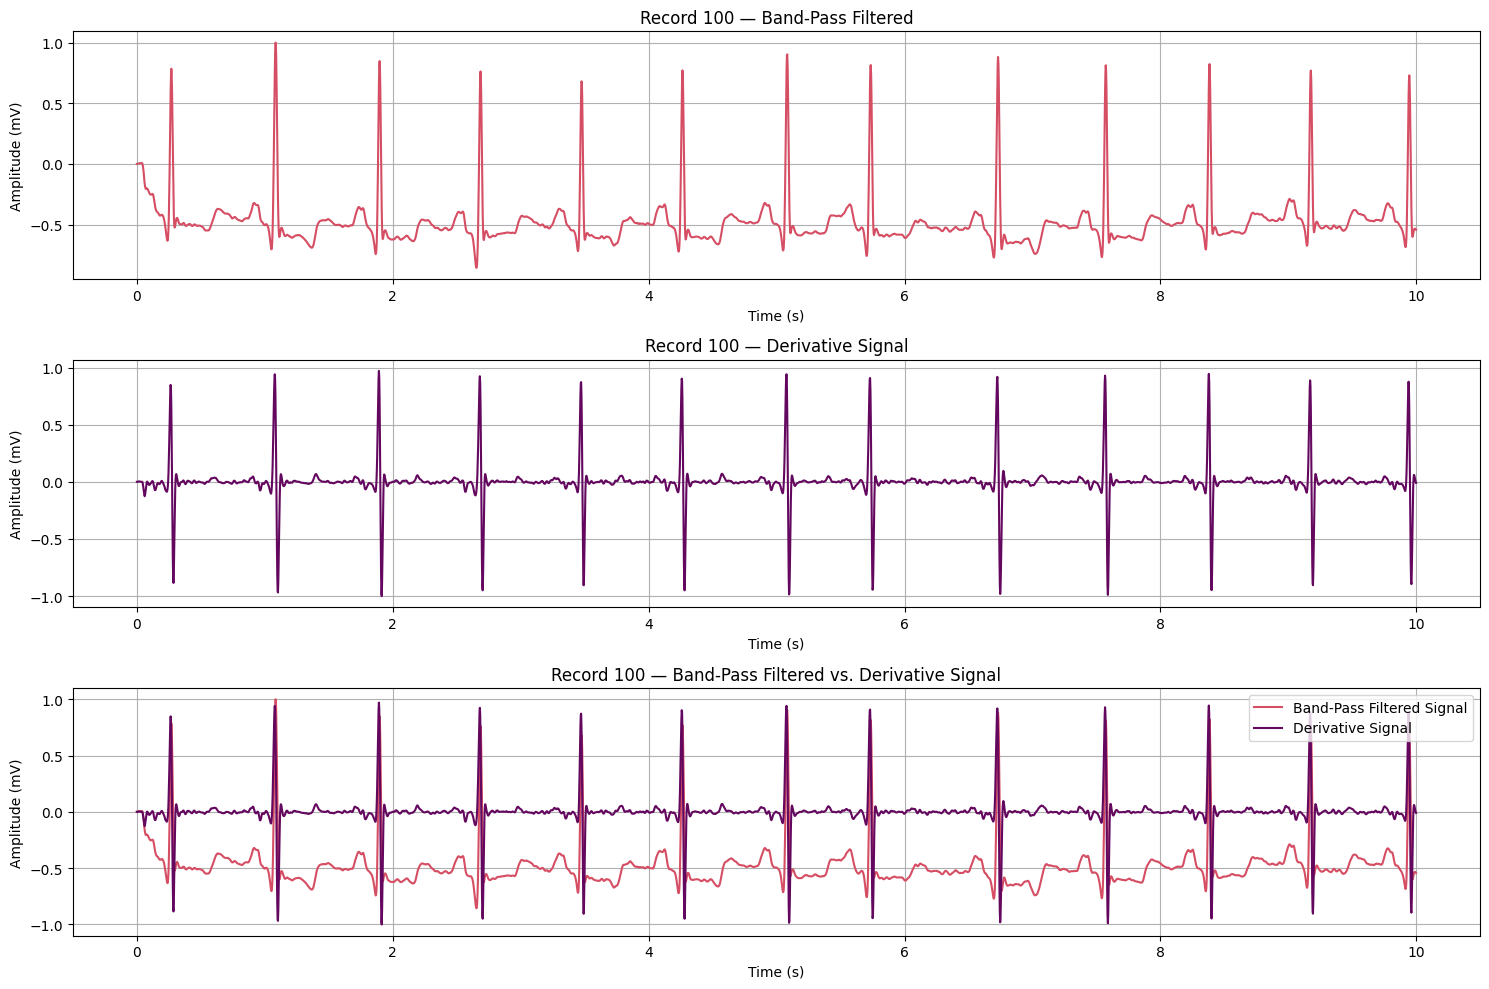

In [16]:
# Normalize for visualization
normalized_derivative = y_derivative_pad / np.max(np.abs(y_derivative_pad))

# Visualize 
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(ten_sec_ecg_time_org, normalized_filtered, color="#d54e63")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Band-Pass Filtered")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(ten_sec_ecg_time_org, normalized_derivative, color="#64075f")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Derivative Signal")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(ten_sec_ecg_time_org, normalized_filtered, color="#d54e63", label="Band-Pass Filtered Signal")
plt.plot(ten_sec_ecg_time_org, normalized_derivative, color="#64075f", label="Derivative Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Band-Pass Filtered vs. Derivative Signal")
plt.grid()

plt.legend()
plt.tight_layout()
plt.show()

## 5. Square

In [17]:
# History / Memory for square: This is for performance and opersation
#  but to be able to visualize the results
y_square_hist = []

In [18]:
def square(sample:float):
    """
    Square one incoming ECG sample in the online Pan-Tompkins pipeline.

    Parameters
    ----------
    sample : float
        Current derivative sample.

    Returns
    -------
    float
        Squared value of the input sample.

    Notes
    -----
    The squaring operation is applied independently to each incoming
    derivative sample according to:

        y[n] = x[n]^2

    The squared output is stored in `y_square_hist` for inspection
    and visualization of the processed signal. The history is not
    required for the squaring operation itself.
    """

    # Apply squaring on the sample
    y_square = sample ** 2

    # Add the output to the outputs list
    y_square_hist.append(y_square)

    return y_square


In [19]:
# Clear history
input_history.clear()
lp_history.clear()
hp_history.clear()
derivative_history.clear()
y_derivative.clear()
y_square_hist.clear()

# Just to inspect and test, we simulate the real-time sampling 
for sample_sq in ten_sec_ecg_sig_org:
    filtered_sample = band_pass_filter(sample_sq)
    derivative_sample = derivative(filtered_sample, fs_original)
    squared_sample = square(derivative_sample)

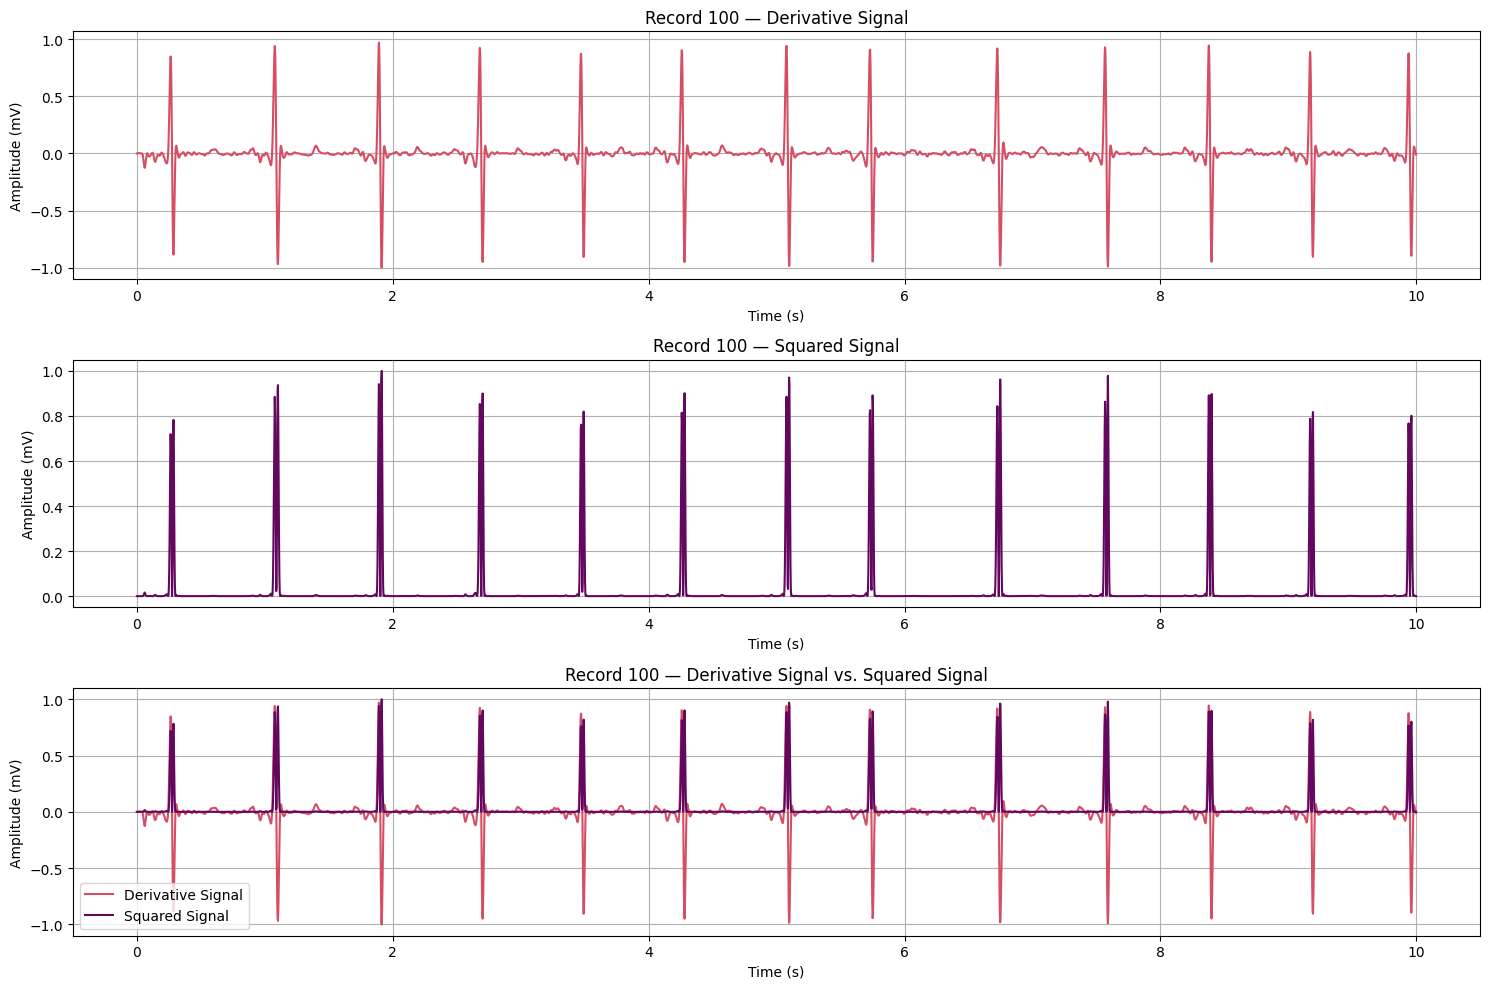

In [20]:
# Normalize for visualization
normalized_squared = y_square_hist / np.max(np.abs(y_square_hist))

# Visualize 
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(ten_sec_ecg_time_org, normalized_derivative, color="#d54e63")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Derivative Signal")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(ten_sec_ecg_time_org, normalized_squared, color="#64075f")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Squared Signal")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(ten_sec_ecg_time_org, normalized_derivative, color="#d54e63", label="Derivative Signal")
plt.plot(ten_sec_ecg_time_org, normalized_squared, color="#64075f", label="Squared Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Derivative Signal vs. Squared Signal")
plt.grid()

plt.legend()
plt.tight_layout()
plt.show()

## 6. Moving-Window Integration (MWI)
The purpose of MWI is to combine the squared signal over a short time window, producing a smoother representation of the energy associated with the QRS complex.

In [21]:
# History / Memory
mwi_history = []
y_integrated = []

# Running sum of the current MWI window
window_sum = 0.0

In [22]:
def moving_window_integration(sample:float, fs:float, window_duration:float=0.15):
    """
    Compute the moving-window integration of one incoming ECG sample.

    The method implements the moving-window integration stage of the
    Pan-Tompkins QRS detection algorithm in an online manner. A fixed
    integration window is maintained over the most recent samples. Once
    the first complete window is available, its mean is calculated.
    For every subsequent sample, the running window sum is updated by
    adding the newest sample and removing the oldest sample, avoiding
    recalculation of the entire window.

    Parameters
    ----------
    sample : float
        Current incoming sample of the squared ECG signal.
    fs : float
        Sampling frequency of the input signal in Hz.
    window_duration : float, optional
        Duration of the moving integration window in seconds.
        Default is 0.15 seconds.

    Returns
    -------
    y_mwi : float or None
        Current moving-window integrated value. Returns ``None`` until
        the first complete integration window has been accumulated.

    Notes
    -----
    The window length is calculated as:

        N = int(window_duration * fs)

    For a complete window, the integrated output is:

        y[n] = (1/N) * sum(x[n-k]),  k = 0, ..., N-1

    During online processing, the running sum is updated recursively:

        S[n] = S[n-1] + x[n] - x[n-N]

    This avoids recalculating the sum of all samples in the window
    for every incoming sample.
    """

    global window_sum

    # Calculate window size
    window_size = int(window_duration * fs)

    # Store the incoming sample
    mwi_history.append(sample)

    # Number of samples currently available
    n_samples = len(mwi_history)

    # Not enough samples for a complete window yet
    if n_samples < window_size:
        return None

    # First complete window
    if n_samples == window_size:
        # Sum of all samples in the first complete window
        window_sum = np.sum(mwi_history[:window_size])

    # Every subsequent sample: slide the window
    else:
        # Add the newest sample
        window_sum += mwi_history[-1]

        # Remove the oldest sample leaving the window
        window_sum -= mwi_history[-window_size - 1]

    # Calculate the moving average
    y_mwi = window_sum / window_size

    # Store output for inspection/visualization
    y_integrated.append(y_mwi)

    return y_mwi

In [23]:
# Clear history
input_history.clear()
lp_history.clear()
hp_history.clear()
derivative_history.clear()
y_derivative.clear()
y_square_hist.clear()
mwi_history.clear()
y_integrated.clear()
window_sum = 0.0

# Just to inspect and test, we simulate the real-time sampling 
for sample_ing in ten_sec_ecg_sig_org:
    filtered_sample = band_pass_filter(sample_ing)
    derivative_sample = derivative(filtered_sample, fs_original)
    squared_sample = square(derivative_sample)
    integrated_sample = moving_window_integration(squared_sample, fs_original)

In [24]:
z_padding = [0.0 for _ in range(53)]
y_integrated_pad = z_padding + y_integrated

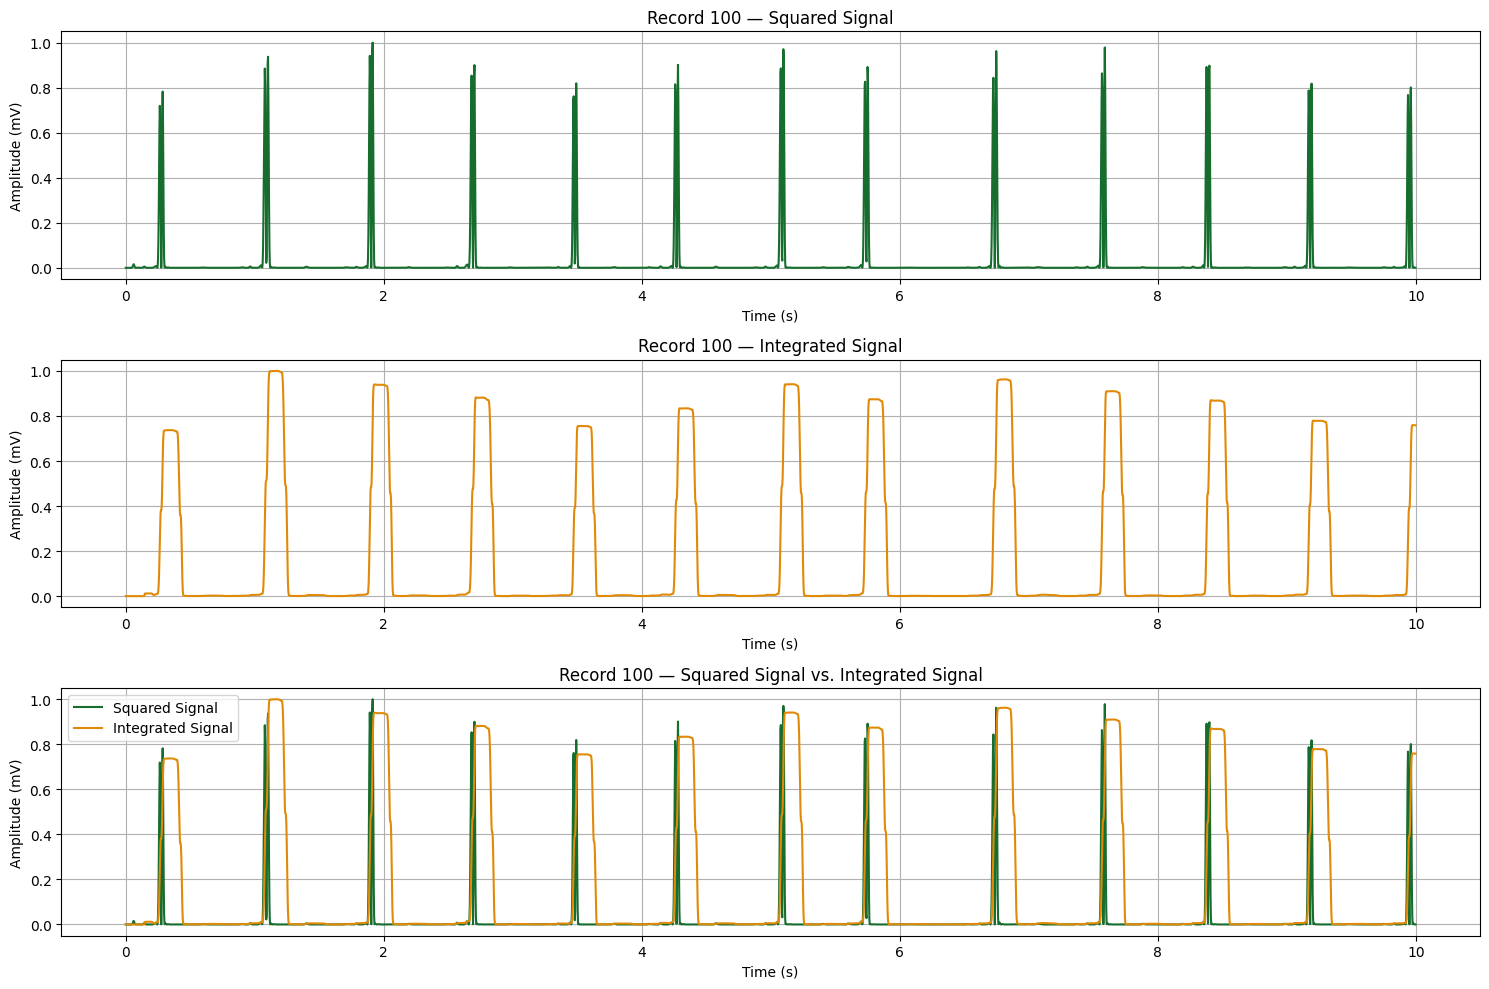

In [25]:
# Normalize for visualization
normalized_integrated = y_integrated_pad / np.max(np.abs(y_integrated_pad))

# Visualize 
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(ten_sec_ecg_time_org, normalized_squared, color="#166d2e")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Squared Signal")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(ten_sec_ecg_time_org, normalized_integrated, color="#e18a08")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Integrated Signal")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(ten_sec_ecg_time_org, normalized_squared, color="#166d2e", label="Squared Signal")
plt.plot(ten_sec_ecg_time_org, normalized_integrated, color="#e18a08", label="Integrated Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Squared Signal vs. Integrated Signal")
plt.grid()

plt.legend()
plt.tight_layout()
plt.show()

## 7. Local Peaks Detection

In [26]:
# History / Memory
local_pks_history = []
peaks_hist = []
peaks_indices_hist = []

In [27]:
def detect_peaks(sample:float):
    """
    Detect local maxima in the moving-window-integrated ECG signal.

    A sample is identified as a local peak when it is greater than the
    preceding sample and greater than or equal to the following sample.
    Because the following sample is required for the comparison, the
    candidate peak is evaluated with a one-sample delay.

    Parameters
    ----------
    sample : float
        Current incoming sample from the moving-window-integrated signal.

    Returns
    -------
    y_loc_pk : float or None
        Amplitude of the detected local peak. Returns None when no peak
        can be confirmed.
    y_loc_pk_index : int or None
        Sample index of the detected local peak. Returns None when no
        peak is detected.

    Notes
    -----
    This method performs basic local-maximum detection without applying
    amplitude thresholds, a refractory period, or adaptive peak selection.
    These operations are handled by subsequent stages of the Pan-Tompkins
    algorithm.

    Mathematical statement: 
         x[n] > x[n−1] & x[n] ≥ x[n+1]
    """

    # Handle missing samples
    if sample is None:
        sample = 0.0

    # Store the incoming sample
    local_pks_history.append(sample)

    # Initialize outputs
    y_loc_pk = None
    y_loc_pk_index = None

    # Current sample index
    n = len(local_pks_history) - 1

    # At least three samples are required
    if len(local_pks_history) >= 3:

        # The middle sample is the candidate
        center = n - 1

        # Check whether the candidate is a local maximum
        if (
            local_pks_history[center] > local_pks_history[center - 1]
            and
            local_pks_history[center] >= local_pks_history[center + 1]
        ):

            # Store detected peak
            y_loc_pk = local_pks_history[center]
            y_loc_pk_index = center

            # Store peak and index
            peaks_hist.append(y_loc_pk)
            peaks_indices_hist.append(y_loc_pk_index)

    else:
        return (None, None)

    return y_loc_pk, y_loc_pk_index

In [28]:
# Clear history
input_history.clear()
lp_history.clear()
hp_history.clear()
derivative_history.clear()
y_derivative.clear()
y_square_hist.clear()
mwi_history.clear()
y_integrated.clear()
window_sum = 0.0
local_pks_history.clear()
peaks_hist.clear()
peaks_indices_hist.clear()

# Just to inspect and test, we simulate the real-time sampling 
for sample_det_pk in ten_sec_ecg_sig_org:
    filtered_sample = band_pass_filter(sample_det_pk)
    derivative_sample = derivative(filtered_sample, fs_original)
    squared_sample = square(derivative_sample)
    integrated_sample = moving_window_integration(squared_sample, fs_original)
    loc_peak, loc_pk_index = detect_peaks(integrated_sample)

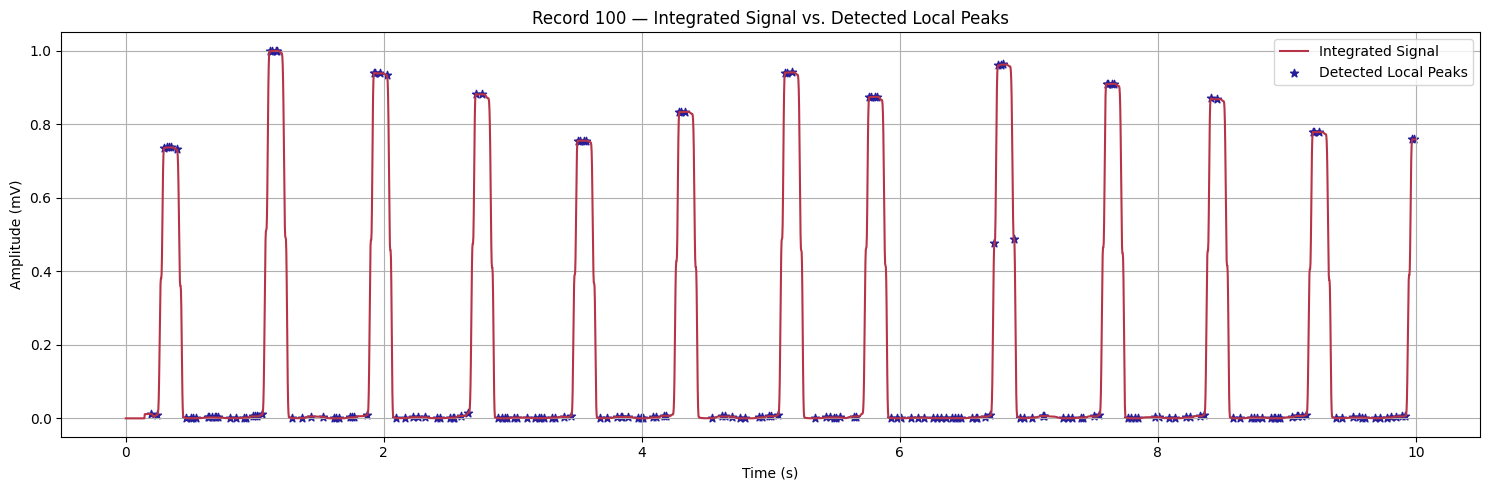

In [29]:
# normalize for plotting
normalized_peaks_hist = peaks_hist / np.max(np.abs(peaks_hist))

# Visualize 
plt.figure(figsize=(15, 5))

plt.plot(ten_sec_ecg_time_org, normalized_integrated, color="#b73347", label="Integrated Signal")
plt.scatter((np.array(peaks_indices_hist) / fs_original), normalized_peaks_hist, color="#261e98", marker="*", label="Detected Local Peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Integrated Signal vs. Detected Local Peaks")
plt.legend()
plt.grid() 
plt.tight_layout()
plt.show()

## 8. Adaptive Threshold Online

In [30]:
# History / Memory
initial_samples_history = []
initial_samples_index_history = []

spk_hist = []
spk_index_hist = []

npk_hist = []
npk_index_hist = []

thre1_hist = []
thre1_index_hist = []
thre2_hist = []
thre2_index_hist = []

y_adopted_peaks = []
y_adopted_peaks_indices = []
y_adopted_noises = []
y_adopted_noises_indices = []

initialization_complete = False
SPK = None
NPK = None
THRESHOLD_1 = None
THRESHOLD_2 = None

In [31]:
def adoptive_threshold_online(
    sample: float,
    sample_index: int,
    peak: float | None,
    peak_index: int | None,
    fs: float
):
    """
    Perform the online adaptive thresholding stage of the
    Pan-Tompkins QRS detection algorithm.

    The function first performs a two-second initialization period
    to estimate the initial signal peak level (SPK), noise peak level
    (NPK), and adaptive thresholds. After initialization, each detected
    candidate peak is classified as either a signal peak or a noise
    peak using the primary adaptive threshold. The corresponding
    SPK or NPK estimate is then updated, followed by recalculation
    of the adaptive thresholds.

    Parameters
    ----------
    sample : float
        Current incoming sample from the signal stream. During the
        initialization period, these samples are collected to estimate
        the initial signal and noise peak levels.

    sample_index : int
        Index of the current incoming sample in the signal stream.

    peak : float or None
        Current local peak candidate detected from the moving-window
        integrated signal. If no candidate peak is available at the
        current step, this should be None.

    peak_index : int or None
        Sample index corresponding to the current candidate peak.

    fs : float
        Sampling frequency of the input signal in Hz.

    Returns
    -------
    classified_peak : float or None
        Candidate peak classified as a signal peak. Returns None when
        the candidate is classified as noise or when the algorithm is
        still in the initialization stage.

    classified_peak_index : int or None
        Sample index corresponding to the classified signal peak.
        Returns None when no signal peak is classified.

    classified_noise : float or None
        Candidate peak classified as a noise peak. Returns None when
        the candidate is classified as a signal peak or when the
        algorithm is still in the initialization stage.

    classified_noise_index : int or None
        Sample index corresponding to the classified noise peak.
        Returns None when no noise peak is classified.

    Notes
    -----
    The first two seconds of the incoming signal are used to initialize
    the adaptive signal and noise peak estimates:

        SPK = 0.25 * max(initial_samples)

        NPK = 0.5 * mean(initial_samples)

    The primary threshold is calculated as:

        THRESHOLD_1 = NPK + 0.25 * (SPK - NPK)

    The secondary threshold is calculated as:

        THRESHOLD_2 = 0.5 * THRESHOLD_1

    After initialization, each candidate peak is classified according
    to the primary threshold.

    For a signal peak:

        SPK[n] = 0.125 * PEAK[n] + 0.875 * SPK[n-1]

    For a noise peak:

        NPK[n] = 0.125 * PEAK[n] + 0.875 * NPK[n-1]

    After each classification, both adaptive thresholds are recalculated.

    The function maintains the adaptive estimates and threshold values
    through global state variables for the current notebook
    implementation. These will later be converted to instance state
    when the algorithm is integrated into the final class.
    """
    
    global SPK, NPK, THRESHOLD_1, THRESHOLD_2
    global initialization_complete

    # Initialize the outputs
    classified_peak = None
    classified_peak_index = None
    classified_noise = None
    classified_noise_index = None

    # Initialization
    if not initialization_complete:

        # Check for sanples in the first 2 seconds
        if (sample_index < 2 * fs) and sample is not None:
            initial_samples_history.append(sample)
            initial_samples_index_history.append(sample_index)

            return 0.0, 0.0, 0.0, 0.0

        if len(initial_samples_history) != 0:
            # Initialize signal peak estimate (SPK) --> SPKI0​ = 0.25 Xmax(Xint​)
            SPK = 0.25 * max(initial_samples_history)
            spk_hist.append(SPK)
            spk_index_hist.append(sample_index)

            # Intialize noise peak estimate (NPK) --> NPK0 ​= 0.5 Xmean(Xint​)
            NPK = 0.5 * np.mean(initial_samples_history)
            npk_hist.append(NPK)
            npk_index_hist.append(sample_index)

            # Initialize threshold 1
            THRESHOLD_1 = NPK + 0.25 * (SPK - NPK)
            thre1_hist.append(THRESHOLD_1)
            thre1_index_hist.append(sample_index)

            # Initialize threshold 2
            THRESHOLD_2 = 0.5 * THRESHOLD_1
            thre2_hist.append(THRESHOLD_2)
            thre2_index_hist.append(sample_index)

            # Set initialization as complete
            initialization_complete = True

            return 0.0, 0.0, 0.0, 0.0

    # No candidate peak
    if peak is None or peak_index is None:
        return None, None, None, None

    # Learning stage / Candidate peak classification

    # Check for peak by comparing to current learned threshold
    if peak > THRESHOLD_1:

        # Update SPK
        SPK = 0.125 * peak + 0.875 * SPK

        # Store adopted peak and its index
        y_adopted_peaks.append(peak)
        y_adopted_peaks_indices.append(peak_index)

        # Assign the peak and its index
        classified_peak = peak
        classified_peak_index = peak_index

        # Store SPK state
        spk_hist.append(SPK)
        spk_index_hist.append(peak_index)

    else:

        # Update NPK
        NPK = 0.125 * peak + 0.875 * NPK

        # Store adopted noise and its index
        y_adopted_noises.append(peak)
        y_adopted_noises_indices.append(peak_index)

        # Assign the noise and its index
        classified_noise = peak
        classified_noise_index = peak_index

        # Store NPK state
        npk_hist.append(NPK)
        npk_index_hist.append(peak_index)

    # Update threshold 1
    THRESHOLD_1 = NPK + 0.25 * (SPK - NPK)
    thre1_hist.append(THRESHOLD_1)
    thre1_index_hist.append(peak_index)

    # Update threshold 2
    THRESHOLD_2 = 0.5 * THRESHOLD_1
    thre2_hist.append(THRESHOLD_2)
    thre2_index_hist.append(peak_index)

    return (
        classified_peak,
        classified_peak_index,
        classified_noise,
        classified_noise_index
    )


In [32]:
# Clear history
input_history.clear()
lp_history.clear()
hp_history.clear()

derivative_history.clear()
y_derivative.clear()

y_square_hist.clear()

mwi_history.clear()
y_integrated.clear()
window_sum = 0.0

local_pks_history.clear()
peaks_hist.clear()
peaks_indices_hist.clear()

initial_samples_history.clear()
initial_samples_index_history.clear()
spk_hist.clear()
npk_hist.clear()
thre1_hist.clear()
thre2_hist.clear()
spk_index_hist.clear()
npk_index_hist.clear()
thre1_index_hist.clear()
thre2_index_hist.clear()
y_adopted_peaks.clear()
y_adopted_peaks_indices.clear()
y_adopted_noises.clear()
y_adopted_noises_indices.clear()

initialization_complete = False
SPK = None
NPK = None
THRESHOLD_1 = None
THRESHOLD_2 = None

In [33]:
# Just to inspect and test, we simulate the real-time sampling
for sample_index_ado, sample_ado in enumerate(ten_sec_ecg_sig_org):
    filtered_sample = band_pass_filter(sample_ado)
    derivative_sample = derivative(filtered_sample, fs_original)
    squared_sample = square(derivative_sample)
    integrated_sample = moving_window_integration(squared_sample, fs_original)
    loc_peak, loc_pk_index = detect_peaks(integrated_sample)
    (
        classified_peak,
        classified_peak_index,
        classified_noise,
        classified_noise_index
    ) = adoptive_threshold_online(
        integrated_sample,
        sample_index_ado,
        loc_peak,
        loc_pk_index,
        fs_original
    )

In [34]:
# Normalize values for visualization
normalization_factor = np.max(np.abs(y_integrated_pad)) # Reference

normalized_adopted_peaks = (
    np.asarray(y_adopted_peaks) / normalization_factor
)

normalized_adopted_noises = (
    np.asarray(y_adopted_noises) / normalization_factor
)

normalized_threshold_1 = THRESHOLD_1 / normalization_factor

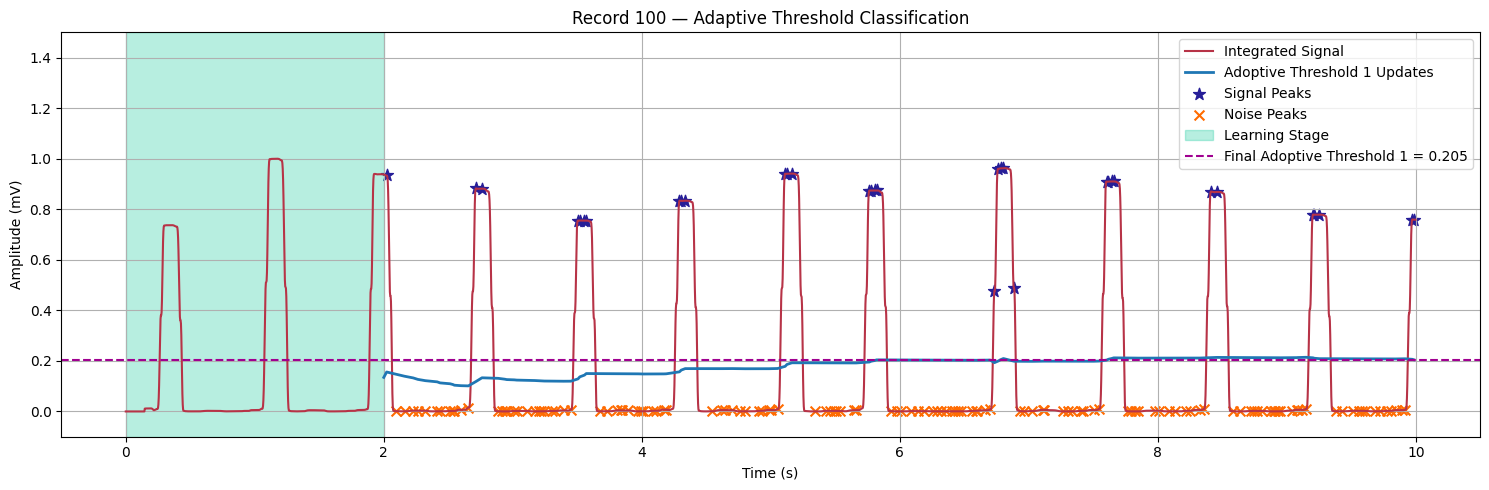

In [35]:
plt.figure(figsize=(15, 5))

plt.plot(
    ten_sec_ecg_time_org,
    normalized_integrated,
    color="#b73347",
    label="Integrated Signal"
)

plt.plot(
    np.asarray(thre1_index_hist) / fs_original,
    np.asarray(thre1_hist) / normalization_factor,
    linewidth=2,
    label="Adoptive Threshold 1 Updates"
)

plt.scatter(
    np.asarray(y_adopted_peaks_indices) / fs_original,
    normalized_adopted_peaks,
    color="#261e98",
    marker="*",
    s=80,
    label="Signal Peaks"
)

plt.scatter(
    np.asarray(y_adopted_noises_indices) / fs_original,
    normalized_adopted_noises,
    color="#ff6b00",
    marker="x",
    s=50,
    label="Noise Peaks"
)

plt.fill_betweenx([-0.1, 1.5], 0, 2, color="#11c99b", alpha=0.3, label="Learning Stage")

plt.axhline(normalized_threshold_1, color="#a00090", linestyle="--",
             label=f"Final Adoptive Threshold 1 = {normalized_threshold_1:.3f}")

plt.ylim(-0.1, 1.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Adaptive Threshold Classification")
plt.legend(loc="upper right")
plt.grid()
plt.tight_layout()
plt.show()

### - Plot Adoptive Parameter Updates

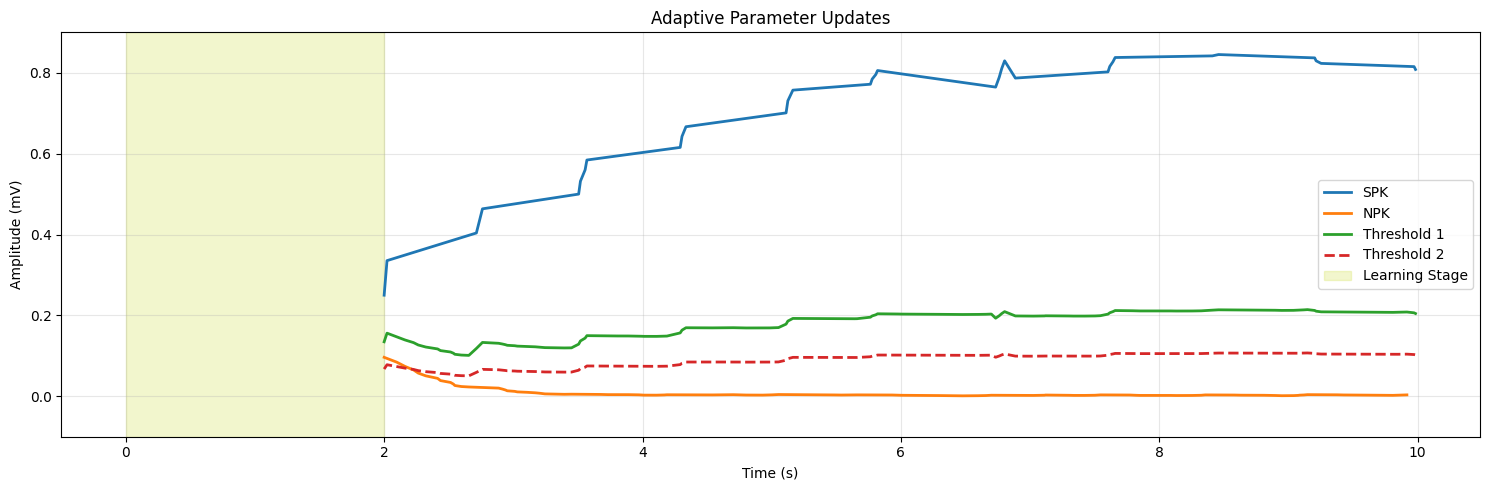

In [36]:
plt.figure(figsize=(15, 5))

plt.plot(
    np.asarray(spk_index_hist) / fs_original,
    np.asarray(spk_hist) / normalization_factor,
    linewidth=2,
    label="SPK"
)

plt.plot(
    np.asarray(npk_index_hist) / fs_original,
    np.asarray(npk_hist) / normalization_factor,
    linewidth=2,
    label="NPK"
)

plt.plot(
    np.asarray(thre1_index_hist) / fs_original,
    np.asarray(thre1_hist) / normalization_factor,
    linewidth=2,
    label="Threshold 1"
)

plt.plot(
    np.asarray(thre2_index_hist) / fs_original,
    np.asarray(thre2_hist) / normalization_factor,
    linewidth=2,
    linestyle="--",
    label="Threshold 2"
)

plt.fill_betweenx([-0.1, 0.9], 0, 2, color="#d6e35b", alpha=0.3, label="Learning Stage")

plt.ylim(-0.1, 0.9)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Adaptive Parameter Updates")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Refractory Period

In [37]:
# History / Memory
refractory_period_history_pk = []
refractory_period_history_id = []
accepted_peaks = []
accepted_indices = []

In [38]:
def refractory_period(peak:float, peak_index:int, fs:float, refractory_time:float=0.2):
    """
    Apply a refractory period to incoming ECG peak candidates.

    The refractory period prevents two closely spaced peak candidates
    from being accepted as separate QRS complexes. A candidate is
    accepted when its sample index is sufficiently distant from the
    most recently accepted candidate. If a new candidate occurs within
    the refractory period, its amplitude is compared with the most
    recently accepted candidate and the stronger candidate is retained.

    Parameters
    ----------
    peak : float
        Amplitude of the incoming peak candidate.
    peak_index : int
        Sample index of the incoming peak candidate.
    fs : float
        Sampling frequency of the ECG signal in Hz.
    refractory_time : float, optional
        Minimum allowed time between accepted peak candidates, in
        seconds. Default is 0.2 seconds (200 ms).

    Returns
    -------
    y_acc_peak : float or None
        Accepted peak amplitude. Returns ``None`` when the incoming
        candidate is rejected and does not replace the previous
        accepted candidate.
    y_acc_peak_index : int or None
        Sample index corresponding to ``y_acc_peak``. Returns ``None``
        when the incoming candidate is rejected.

    Notes
    -----
    The refractory period is converted from seconds to samples as:

        N = refractory_time * fs

    The online implementation processes one candidate at a time and
    therefore maintains the previously accepted peaks and their
    indices as persistent state.

    If a candidate occurs within the refractory period of the previous
    accepted candidate, the candidate with the greater amplitude is
    retained.
    """
    # Handle missing samples
    if peak is None or peak_index is None:
        return None, None
    
    # Calculate number of refractory samples 
    #   = Minimum allowed distance between accepted peaks
    N = int(refractory_time * fs)

    # Store the incoming peak and index
    refractory_period_history_pk.append(peak)
    refractory_period_history_id.append(peak_index)

    # Initialize outputs
    y_acc_peak = None
    y_acc_peak_index = None

    # Check for the first candidate
    if len(accepted_indices) == 0:

        # Assign peak and index
        y_acc_peak = peak
        y_acc_peak_index = peak_index

        # Store the first candidate
        accepted_peaks.append(peak)
        accepted_indices.append(peak_index)

    else:
        # Calculate distance from last accepted candidate 
        distance = (peak_index - accepted_indices[-1]) 

        # Compare distance with allowed refractory period
        if distance >= N: 

            # If true, one peak is outside the other's refractory period 
            y_acc_peak = peak
            y_acc_peak_index = peak_index

            # Store peak and index
            accepted_peaks.append(y_acc_peak)
            accepted_indices.append(y_acc_peak_index)

        else:
            # If false, the two local peaks are 
            #   inside the same refractory period so 
            #   check their amplitude to select the strongest
            if peak > accepted_peaks[-1]:

                # Assign the strongest peak
                y_acc_peak = peak
                y_acc_peak_index = peak_index

                # Store the strongest peak and its index
                accepted_peaks[-1] = y_acc_peak
                accepted_indices[-1] = y_acc_peak_index

    return y_acc_peak, y_acc_peak_index


In [39]:
# Clear history
input_history.clear()
lp_history.clear()
hp_history.clear()

derivative_history.clear()
y_derivative.clear()

y_square_hist.clear()

mwi_history.clear()
y_integrated.clear()
window_sum = 0.0

local_pks_history.clear()
peaks_hist.clear()
peaks_indices_hist.clear()

refractory_period_history_pk.clear()
refractory_period_history_id.clear()

accepted_peaks.clear()
accepted_indices.clear()

initial_samples_history.clear()
initial_samples_index_history.clear()
spk_hist.clear()
npk_hist.clear()
thre1_hist.clear()
thre2_hist.clear()
spk_index_hist.clear()
npk_index_hist.clear()
thre1_index_hist.clear()
thre2_index_hist.clear()
y_adopted_peaks.clear()
y_adopted_peaks_indices.clear()
y_adopted_noises.clear()
y_adopted_noises_indices.clear()

initialization_complete = False
SPK = None
NPK = None
THRESHOLD_1 = None
THRESHOLD_2 = None

In [40]:
# Just to inspect and test, we simulate the real-time sampling
for sample_index_ado, sample_ado in enumerate(ten_sec_ecg_sig_org):
    filtered_sample = band_pass_filter(sample_ado)
    derivative_sample = derivative(filtered_sample, fs_original)
    squared_sample = square(derivative_sample)
    integrated_sample = moving_window_integration(squared_sample, fs_original)
    loc_peak, loc_pk_index = detect_peaks(integrated_sample)
    (
        classified_peak,
        classified_peak_index,
        classified_noise,
        classified_noise_index
    ) = adoptive_threshold_online(
        integrated_sample,
        sample_index_ado,
        loc_peak,
        loc_pk_index,
        fs_original
    )

    y_acc_peak, y_acc_peak_index = refractory_period(
        classified_peak,
        classified_peak_index,
        fs_original
    )

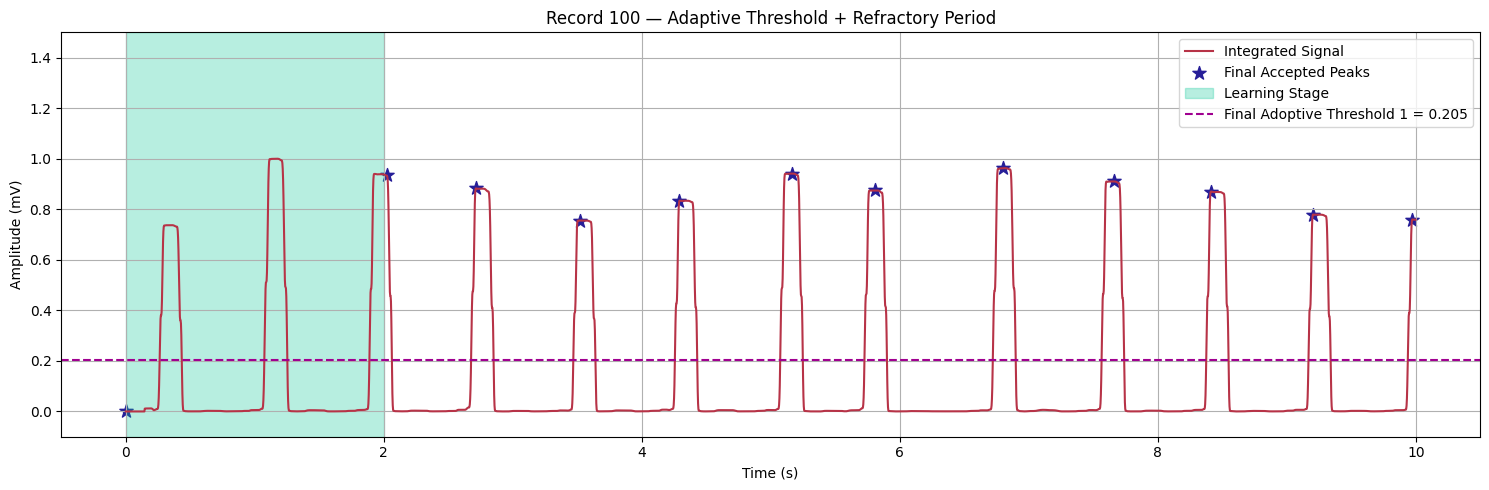

In [41]:
# normalize for plotting
normalized_accepted_peaks = (np.asarray(accepted_peaks) / normalization_factor)

plt.figure(figsize=(15, 5))

plt.plot(
    ten_sec_ecg_time_org,
    normalized_integrated,
    color="#b73347",
    label="Integrated Signal"
)

#plt.plot(ten_sec_ecg_time_org, normalized_filtered, color="#2e8d05")

plt.scatter(
    np.asarray(accepted_indices) / fs_original,
    normalized_accepted_peaks,
    color="#261e98",
    marker="*",
    s=100,
    label="Final Accepted Peaks"
)

plt.fill_betweenx(
    [-0.1, 1.5],
    0, 2, color="#11c99b", alpha=0.3, label="Learning Stage"
)

plt.axhline(normalized_threshold_1, color="#a00090", linestyle="--",
             label=f"Final Adoptive Threshold 1 = {normalized_threshold_1:.3f}")

plt.ylim(-0.1, 1.5)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — Adaptive Threshold + Refractory Period")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## 10. Search Back

In [46]:
# Dedicated memory for search-back
search_back_peaks = []          # amplitudes of peaks found by search-back
search_back_indices = []        # their absolute indices
search_back_flags = []          # True if search-back actually replaced a candidate

filtered_history = []          
filtered_index_history = []   

In [ ]:
def search_back(
    candidate_peak: float | None,
    candidate_index: int | None,
    fs: float,
    search_back_time: float = 1.66,          # classic Pan-Tompkins value (~1660 ms)
    mwi_delay: int | None = None
):
    """
    Perform the online search-back stage of the Pan-Tompkins QRS detection algorithm.

    When a candidate peak fails the primary adaptive threshold (THRESHOLD_1)
    but is still considered, this function looks backward in time (default
    1.66 seconds) for a stronger peak that exceeds the secondary adaptive
    threshold (THRESHOLD_2). If such a peak is found, it replaces the original
    candidate.

    The function maintains its own dedicated history lists so that the results
    of search-back can be inspected and plotted independently of the main
    accepted-peak lists.

    Parameters
    ----------
    candidate_peak : float or None
        Amplitude of the current candidate peak (from the integrated signal).
        Pass None when no candidate is available.

    candidate_index : int or None
        Absolute sample index of the current candidate (MWI timeline).
        Pass None when no candidate is available.

    fs : float
        Sampling frequency of the ECG signal in Hz.

    search_back_time : float, optional
        Maximum time to look backward from the candidate, in seconds.
        Default is 1.66 s (classic Pan-Tompkins value).

    mwi_delay : int or None, optional
        Approximate delay (in samples) between the filtered signal and the
        moving-window integrated signal. Defaults to int(0.15 * fs) - 1.

    Returns
    -------
    final_peak : float or None
        Amplitude of the accepted peak after search-back.
        Returns the original candidate if no better peak is found,
        or None if the input candidate was None.

    final_index : int or None
        Absolute sample index of the accepted peak after search-back.

    is_replaced : bool
        True if a stronger peak was found by search-back and replaced
        the original candidate; False otherwise.

    Notes
    -----
    - The function uses the global adaptive threshold THRESHOLD_2.
    - Only peaks that exceed THRESHOLD_2 are considered valid replacements.
    - Successful replacements are stored in the dedicated lists:
          search_back_peaks, search_back_indices, search_back_flags
    - After a successful search-back the classic Pan-Tompkins algorithm
      updates SPK with the weights 0.25 / 0.75 instead of 0.125 / 0.875.
      That update can be performed by the caller if desired.
    """

    # Handle missing candidate
    if candidate_peak is None or candidate_index is None:
        return None, None, False

    # Protect against THRESHOLD_2 still being None (learning phase)
    if THRESHOLD_2 is None:
        return candidate_peak, candidate_index, False

    # Default delay compensation
    if mwi_delay is None:
        mwi_delay = int(0.15 * fs) - 1

    # Number of samples to look back
    N = int(search_back_time * fs)

    # Search region in the filtered-signal timeline
    search_end   = max(0, candidate_index - mwi_delay)
    search_start = max(0, search_end - N)

    # Search for the strongest peak that exceeds THRESHOLD_2
    best_peak  = None
    best_index = None

    for i, idx in enumerate(filtered_index_history):
        if idx < search_start:
            continue
        if idx > search_end:
            break

        # Robust amplitude extraction
        amp = filtered_history[i] if filtered_history[i] is not None else 0.0

        if amp > THRESHOLD_2:
            if best_peak is None or abs(amp) > abs(best_peak):
                best_peak  = amp
                best_index = idx

    # Decide whether a replacement occurred
    is_replaced = False

    if best_peak is not None:
        search_back_peaks.append(best_peak)
        search_back_indices.append(best_index)
        search_back_flags.append(True)

        final_peak  = best_peak
        final_index = best_index
        is_replaced = True
    else:
        search_back_flags.append(False)

        final_peak  = candidate_peak
        final_index = candidate_index
        is_replaced = False

    return final_peak, final_index, is_replaced

In [48]:
# Clear history
input_history.clear()
lp_history.clear()
hp_history.clear()

derivative_history.clear()
y_derivative.clear()

y_square_hist.clear()

mwi_history.clear()
y_integrated.clear()
window_sum = 0.0

local_pks_history.clear()
peaks_hist.clear()
peaks_indices_hist.clear()

refractory_period_history_pk.clear()
refractory_period_history_id.clear()

accepted_peaks.clear()
accepted_indices.clear()

initial_samples_history.clear()
initial_samples_index_history.clear()
spk_hist.clear()
npk_hist.clear()
thre1_hist.clear()
thre2_hist.clear()
spk_index_hist.clear()
npk_index_hist.clear()
thre1_index_hist.clear()
thre2_index_hist.clear()
y_adopted_peaks.clear()
y_adopted_peaks_indices.clear()
y_adopted_noises.clear()
y_adopted_noises_indices.clear()
        
search_back_peaks.clear()         
search_back_indices.clear()       
search_back_flags.clear()  
filtered_history.clear()          
filtered_index_history.clear()  

initialization_complete = False
SPK = None
NPK = None
THRESHOLD_1 = None
THRESHOLD_2 = None

In [49]:
# Just to inspect and test, we simulate the real-time sampling
for sample_index_ado, sample_ado in enumerate(ten_sec_ecg_sig_org):
    filtered_sample = band_pass_filter(sample_ado)

    # Store filtered sample and its index immediately
    filtered_history.append(filtered_sample)
    filtered_index_history.append(sample_index_ado)

    derivative_sample = derivative(filtered_sample, fs_original)
    squared_sample = square(derivative_sample)
    integrated_sample = moving_window_integration(squared_sample, fs_original)
    loc_peak, loc_pk_index = detect_peaks(integrated_sample)
    (
        classified_peak,
        classified_peak_index,
        classified_noise,
        classified_noise_index
    ) = adoptive_threshold_online(
        integrated_sample,
        sample_index_ado,
        loc_peak,
        loc_pk_index,
        fs_original
    )

    y_acc_peak, y_acc_peak_index = refractory_period(
        classified_peak,
        classified_peak_index,
        fs_original
    )

    final_peak, final_index, was_replaced = search_back(
        y_acc_peak,
        y_acc_peak_index,
        fs_original
    )
    if final_peak and final_index:
        print(final_peak, final_index)

206421618.46593735 728
195166479.77718714 977
166960751.5434372 1262
167013108.5446872 1267
184378997.90249938 1545
207946536.08343652 1840
208098786.1303116 1859
193233687.35156152 2075
193273264.03499925 2080
193360971.7096866 2090
105593245.51125276 2424
212254014.55124858 2434
212662786.52718657 2441
212833029.76312393 2449
201089155.83187416 2737
201109689.59999958 2742
201205402.6799995 2751
201212571.86156213 2757
192376581.2849991 3028
172284958.80843708 3313
167897140.67999914 3590


## 11. R-Peaks Localization

In [50]:
pending_candidates = []       
localized_r_peak_hist = []
localized_r_peak_index_hist = []

In [51]:
def localize_r_peak(
    sample_index: int,
    candidate_index: int | None,
    fs: float,
    search_window: int | None = None,
    mwi_delay: int | None = None
):
    """
    Localize the exact R-peak in the band-pass filtered ECG signal around a candidate
    detected from the moving-window integrated signal.

    The function works fully online. It assumes that every filtered sample has already
    been stored in the global lists ``filtered_history`` and ``filtered_index_history``
    (this is done in the main processing loop right after the band-pass filter).
    Candidates are queued until their complete search window is available, then the
    strongest peak (absolute maximum) inside that window is returned.

    Parameters
    ----------
    sample_index : int
        Absolute sample index of the current time step (used to decide when the
        search window is complete).

    candidate_index : int | None
        Candidate index originating from the moving-window integrated signal
        (after peak detection, adaptive thresholding, refractory period and
        optional search-back). This index refers to the MWI timeline.

    fs : float
        Sampling frequency of the ECG signal in Hz.

    search_window : int | None, optional
        Number of samples to search on either side of the candidate.
        Defaults to 15 % of one second (0.15 * fs).

    mwi_delay : int | None, optional
        Approximate delay (in samples) between the filtered signal and the
        moving-window integrated signal. Defaults to ``search_window - 1``.
        This constant can be fine-tuned offline for better sample-level alignment.

    Returns
    -------
    localized_r_peak : float | None
        Amplitude of the localized R-peak. Returns ``None`` while the search
        window is still incomplete.

    localized_r_peak_index : int | None
        Absolute sample index (in the original recording) of the localized R-peak.
        Returns ``None`` while the search window is still incomplete.

    Notes
    -----
    - The filtered signal history must be maintained outside this function:
        filtered_history        → list of amplitude values
        filtered_index_history  → list of absolute sample indices
    - Candidates are stored in the global queue ``pending_candidates`` until
      their complete search window is available.
    - Localization uses the absolute maximum (``np.argmax(np.abs(area))``) so
      both positive and negative R-peaks are correctly identified.
    - The function is designed for real-time, sample-by-sample processing.
    """

    if search_window is None:
        search_window = int(0.15 * fs)

    if mwi_delay is None:
        mwi_delay = search_window - 1

    # New candidate arrived → estimate where it should appear in the filtered timeline
    if candidate_index is not None:
        target_index = candidate_index - mwi_delay
        pending_candidates.append((candidate_index, target_index))

    if not pending_candidates:
        return None, None

    # Look at the oldest pending candidate
    cand_idx, target_idx = pending_candidates[0]

    # Wait until the right side of the search window has arrived
    if sample_index < target_idx + search_window:
        return None, None

    # Locate the target inside the already-stored filtered history
    try:
        center_pos = filtered_index_history.index(target_idx)
    except ValueError:
        # Target index never appeared (or already fell out of a limited buffer)
        pending_candidates.pop(0)
        return None, None

    lower = max(0, center_pos - search_window)
    upper = min(len(filtered_history) - 1, center_pos + search_window)

    area = np.asarray(filtered_history[lower : upper + 1])
    local_offset = int(np.argmax(np.abs(area)))
    global_pos = lower + local_offset

    localized_r_peak = float(filtered_history[global_pos])
    localized_r_peak_index = filtered_index_history[global_pos]

    localized_r_peak_hist.append(localized_r_peak)
    localized_r_peak_index_hist.append(localized_r_peak_index)

    pending_candidates.pop(0)

    return localized_r_peak, localized_r_peak_index

In [55]:
# Clear history
input_history.clear()
lp_history.clear()
hp_history.clear()

derivative_history.clear()
y_derivative.clear()

y_square_hist.clear()

mwi_history.clear()
y_integrated.clear()
window_sum = 0.0

local_pks_history.clear()
peaks_hist.clear()
peaks_indices_hist.clear()

refractory_period_history_pk.clear()
refractory_period_history_id.clear()

accepted_peaks.clear()
accepted_indices.clear()

initial_samples_history.clear()
initial_samples_index_history.clear()
spk_hist.clear()
npk_hist.clear()
thre1_hist.clear()
thre2_hist.clear()
spk_index_hist.clear()
npk_index_hist.clear()
thre1_index_hist.clear()
thre2_index_hist.clear()
y_adopted_peaks.clear()
y_adopted_peaks_indices.clear()
y_adopted_noises.clear()
y_adopted_noises_indices.clear()

search_back_peaks.clear()         
search_back_indices.clear()       
search_back_flags.clear()    

pending_candidates.clear()       
filtered_history.clear()
filtered_index_history.clear()   
localized_r_peak_hist.clear()
localized_r_peak_index_hist.clear()

initialization_complete = False
SPK = None
NPK = None
THRESHOLD_1 = None
THRESHOLD_2 = None

In [56]:
# Just to inspect and test, we simulate the real-time sampling
for sample_index_ado, sample_ado in enumerate(ten_sec_ecg_sig_org):
    filtered_sample = band_pass_filter(sample_ado)

    # Store filtered sample and its index immediately
    filtered_history.append(filtered_sample)
    filtered_index_history.append(sample_index_ado)

    derivative_sample = derivative(filtered_sample, fs_original)
    squared_sample = square(derivative_sample)
    integrated_sample = moving_window_integration(squared_sample, fs_original)
    loc_peak, loc_pk_index = detect_peaks(integrated_sample)
    (
        classified_peak,
        classified_peak_index,
        classified_noise,
        classified_noise_index
    ) = adoptive_threshold_online(
        integrated_sample,
        sample_index_ado,
        loc_peak,
        loc_pk_index,
        fs_original
    )

    y_acc_peak, y_acc_peak_index = refractory_period(
        classified_peak,
        classified_peak_index,
        fs_original
    )

    final_peak, final_index, was_replaced = search_back(
        y_acc_peak,
        y_acc_peak_index,
        fs_original
    )

    localized_r_peak, localized_r_peak_index = localize_r_peak(
        sample_index_ado,
        final_index,
        fs_original
    )
    

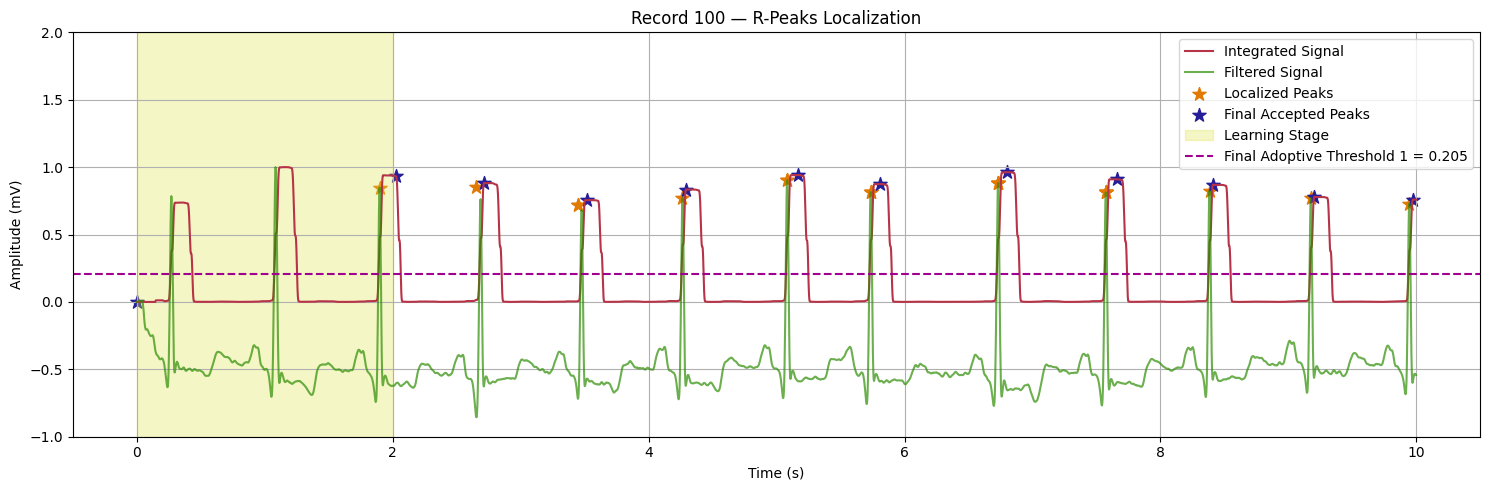

In [57]:
# normalize for plotting
normalized_localized_r_peak_hist = np.abs((np.asarray(localized_r_peak_hist)) / np.max(np.abs(hp_history[:len(ten_sec_ecg_time_org)])))

plt.figure(figsize=(15, 5))

plt.plot(
    ten_sec_ecg_time_org,
    normalized_integrated,
    color="#b73347",
    label="Integrated Signal"
)

plt.plot(
    ten_sec_ecg_time_org,
    normalized_filtered,
    color="#2e8d05",
    alpha=0.7, 
    label="Filtered Signal"
)

plt.scatter(
    np.asarray(localized_r_peak_index_hist) / fs_original,
    normalized_localized_r_peak_hist,
    color="#e17903",
    marker="*",
    s=100,
    label="Localized Peaks"
)

plt.scatter(
    np.asarray(accepted_indices) / fs_original,
    normalized_accepted_peaks,
    color="#261e98",
    marker="*",
    s=100,
    label="Final Accepted Peaks"
)

plt.fill_betweenx(
    [-1, 2],
    0, 2, color="#e0e241", alpha=0.3, label="Learning Stage"
)

plt.axhline(normalized_threshold_1, color="#a00090", linestyle="--",
             label=f"Final Adoptive Threshold 1 = {normalized_threshold_1:.3f}")

plt.ylim(-1, 2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("Record 100 — R-Peaks Localization")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()